### Torus Geometry
- **Triangular unit cell**: Primitive vectors |G₁|=|G₂| with 120 degree in between
- **Landau level**: n = 0 (lowest Landau level)
- **Brillouin zone area**: 2π/l² = √0.75 × G²
- **Magnetic length**: l = √(ℏ/eB) sets the length scale

### Bilayer Parameters
- **Nc_mix or Nc_conserve = 2**: Number of layers (components)
- **Inter-layer distance**: d/l
- **Tunneling amplitude**: t/W0 (when t=0, one can use Nc_conserve to reduce the subspace dimension)
- **Displacement field**: ΔE/W0, energy difference between layers

### Interaction Details
- **Layer conservation**: Interactions preserve layer index of each particle
- **Layer symmetric**: Interactions unchanged if swap the two layer indices
- **Gate Screening**: D/l
- **Different-layer interaction**: Includes e^{-ql*d/l} attenuation factor
- **Form factor**: See arXiv.2509.07784 Eq.(A28) 

### Key Physics
- **(331)-Halperin**: when tunneling is weak, the 1/4 + 1/4 filling is the Halperin phase
- **8-fold ground state degeneracy**: 8 ground states may be not exactly degenerate due to tunneling and finite-size effect

In [1]:
# These packages are not included in the MomentumED package. 
# Use the following line to add them:

# using Pkg; Pkg.add("CairoMakie"); Pkg.add("QuadGK"); Pkg.add("ClassicalOrthogonalPolynomials")

In [2]:
# Import the momentum-conserved exact diagonalization package
using MomentumED, LinearAlgebra
include("../Landau level torus.jl")
using .LLT        # due to the world age, we can only run this once

using CairoMakie # for plotting
CairoMakie.activate!()

# optional MKLSparse can accelecrate the sparse MatVec multiplication, other sparse packages helps as well
# using MKL, MKLSparse
# MKL.BLAS.set_num_threads(1)

In [3]:
# square/triangular lattice
sqa_lattice = ReciprocalLattice(:square);          # == ReciprocalLattice(1, 0)
tri_lattice = ReciprocalLattice(:triangular);      # == ReciprocalLattice(1, -1//2)
# general_lattice = ReciprocalLattice(abs(G2/G1), cos(θ))
# use exact values, Integer or Rational, to avoid uncertainty on Brillouin Zone boundary.

# Plot the energy spectrum
function plot_ed_spectrum(energies, ss_k, Gk::NTuple{2, Int64};
    title = nothing, ylims = (nothing, nothing),
    ylabel = "Energy per unit cell (W₀ = e²/ϵl)",
    top_subspace_number = true)

    fig = Figure();
    ax = Axis(fig[1, 1];
        xlabel = "k1+$(Gk[1])k2",
        ylabel = ylabel
    )
    ax_top = Axis(fig[1, 1];
        xaxisposition = :top
    )
    top_ticks = ([], [])
    hidespines!(ax_top)
    hidexdecorations!(ax_top; label = false, ticklabels = false)
    hideydecorations!(ax_top)
    linkxaxes!(ax, ax_top)

    # Plot energy levels for each momentum block
    for i in eachindex(ss_k)
        x = ss_k[i][1] + Gk[1] * ss_k[i][2]
        push!(top_ticks[1], x)
        push!(top_ticks[2], string(i))
        if isassigned(energies,i)
            for e in energies[i]
                scatter!(ax, x, e, color = :blue, marker=:hline)
            end
        end
    end
    ylims!(ax, ylims...)
    top_subspace_number && (ax_top.xticks = top_ticks)
    if title isa String
        ax_top.subtitle = title
    end
    display(fig)
    fig, ax
end

plot_ed_spectrum (generic function with 1 method)

Define the system and compute the eigen eneneies and wavefunctions, constructing the Hamiltonian as a sparse matrix.

1. Nc_conserve = 2 without tunneling

In [4]:
# Define k-mesh for bilayer system (4×3 mesh, Nk=12) in triangular lattice
k_list = [0 1 2 3 0 1 2 3 0 1 2 3;
          0 0 0 0 1 1 1 1 2 2 2 2]
Nk = 12
Gk = (4, 3)  # Grid dimensions

(4, 3)

In [5]:
function tunneling(k::Int64, cf::Int64, ci::Int64; t_W0::Float64)
    # t_W0 is the tunneling strength in units of W₀ = e²/ϵl
    if cf == ci
        return 0.0
    else
        return t_W0
    end
end

tunneling (generic function with 1 method)

In [6]:
# Set up component parameters: (layer, level index, Chern number, pseudospin)
sys_int = LandauInteraction(tri_lattice,
    (1, 0, 1, 0),
    (2, 0, 1, 0)
); # layer 1 and layer 2

# Coulomb
sys_int.D_l = 10.0                  # Screening length D/l
sys_int.d_l = 2.0                   # Inter-layer distance d/l
# compute the pseudo-potential components
intra_PP = LLT.pseudo_potential_decomposition.(0:15; same_layer = true,  D_l = sys_int.D_l, d_l = sys_int.d_l)
inter_PP = LLT.pseudo_potential_decomposition.(0:15; same_layer = false, D_l = sys_int.D_l, d_l = sys_int.d_l)
@show intra_PP
@show inter_PP

# Haldane
sys_int.V_intra = [0.0; 0.8; 0.0; 0.0]          # Intralayer Haldane pseudo-potential in unit of W0
sys_int.V_inter = [1.0; 0.0; 0.0; 0.0]          # Interlayer Haldane pseudo-potential in unit of W0

# or use Coulomb interaction with a cutoff in m
# sys_int.V_intra = copy(intra_PP)
# sys_int.V_inter = copy(inter_PP)

# choose a linear mixing between Haldane and Coulomb interaction
sys_int.mix = 1                  # mix * Haldane + (1-mix) * Coulomb

# Create parameter structure for bilayer system
para = EDPara(
    k_list = k_list, 
    Gk = Gk, 
    Nc_mix = 1,
    Nc_conserve = 2,
    H_two = sys_int,
);
para_tunnel = EDPara(
    k_list = k_list, 
    Gk = Gk, 
    Nc_mix = 2,
    Nc_conserve = 1,
    H_one = tunneling,
    H_two = sys_int,
);

intra_PP = [1.6326473915475541, 0.7473513096250322, 0.52670982841867, 0.4168315354285451, 0.3484803526664003, 0.30088572250719675, 0.26539345713301177, 0.23767663533849026, 0.21530150818966495, 0.1967809071174104, 0.18114827784359777, 0.16774469758582808, 0.15610350958409644, 0.1458837662763503, 0.13682981995416446, 0.12874573031482742]
inter_PP = [0.6204292660918972, 0.48449255713908407, 0.39848869807091536, 0.33925378440616344, 0.29584034949628485, 0.2625210735936332, 0.23603971504532437, 0.21441527840262628, 0.1963741625881633, 0.18105955427315698, 0.16787293055247338, 0.15638280049734216, 0.14626967038769934, 0.13729150656211703, 0.12926130241866884, 0.12203206399417219]


In [7]:
Ne_total = 6
Ne = (3, 3)

# when there's no tunneling for bilayer system
subspaces, ss_k = ED_momentum_subspaces(para, Ne);
display(collect(zip(length.(subspaces), ss_k)))

# one-body and two-body terms in Hamiltonian
scat1 = ED_scatterlist_onebody(para);
@show isempty(scat1) # para doesn't have H_one, so scat1 will be empty
scat2 = ED_scatterlist_twobody(para);

# construct the Hamiltonian operator from the scatter list
hmlt =  MBOperator(scat2; upper_hermitian = true)

12-element Vector{Tuple{Int64, Tuple{Int64, Int64}}}:
 (4036, (0, 0))
 (4036, (1, 0))
 (4036, (2, 0))
 (4036, (3, 0))
 (4032, (0, 1))
 (4032, (1, 1))
 (4032, (2, 1))
 (4032, (3, 1))
 (4032, (0, 2))
 (4032, (1, 2))
 (4032, (2, 2))
 (4032, (3, 2))

isempty(scat1) = true


Many Body Operator (Hermitian, upper triangle entries only) :
	Vector{EDCore.Scatter{ComplexF64, MBS64{24}}} with 1368 scattering terms


In [8]:
Ne_total = 6
Ne = (3, 3)

# when there is a tunneling, only total electron number is a good quantum number.
subspaces_tunnel, ss_tunnel_k = ED_momentum_subspaces(para_tunnel, Ne_total);
display(collect(zip(length.(subspaces_tunnel), ss_tunnel_k)))
# the subspace dimension is much larger.

# one-body and two-body terms in Hamiltonian
t_W0 = 0.01                  # t/W0
scat1_tunnel = ED_scatterlist_onebody(para_tunnel;
    H_one = (t_W0 = t_W0, ) # additional keyword arguments are passed to the H_one function, e.g., t_W0 in this case
);
@show isempty(scat1_tunnel) # still empty if input t_W0 = 0.0
scat2_tunnel = ED_scatterlist_twobody(para_tunnel);
@show scat2_tunnel == scat2 # para and para_tunnel have the same H_two field

# construct the Hamiltonian operator from the scatter list
hmlt_tunnel =  MBOperator(scat1_tunnel, scat2_tunnel; upper_hermitian = true)

12-element Vector{Tuple{Int64, Tuple{Int64, Int64}}}:
 (11202, (0, 0))
 (11240, (1, 0))
 (11202, (2, 0))
 (11240, (3, 0))
 (11196, (0, 1))
 (11232, (1, 1))
 (11196, (2, 1))
 (11232, (3, 1))
 (11196, (0, 2))
 (11232, (1, 2))
 (11196, (2, 2))
 (11232, (3, 2))

isempty(scat1_tunnel) = false
scat2_tunnel == scat2 = true


Many Body Operator (Hermitian, upper triangle entries only) :
	Vector{EDCore.Scatter{ComplexF64, MBS64{24}}} with 1380 scattering terms


In [9]:
Neigen = 10  # Number of eigenvalues to compute per subspace
ss_range = eachindex(subspaces) # pick some subspaces to compute, e.g., ss_range = 1:5
energies = [Vector{Float64}() for _ in ss_range];
energies_tunnel = [Vector{Float64}() for _ in ss_range];
vectors = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
vectors_tunnel = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
println("Without tunneling:")
for i in eachindex(ss_range)
    println("Processing subspace #$i with size $(length(subspaces[ss_range[i]])), momentum $(ss_k[i])")
    energies[i], vectors[i] = 
    EDsolve(subspaces[ss_range[i]], hmlt;
        N = Neigen, showtime = true, ishermitian = true, method_info = true,
        method = :sparse
    )
end
println("With tunneling:")
for i in eachindex(ss_range)
    println("Processing subspace #$i with size $(length(subspaces_tunnel[ss_range[i]])), momentum $(ss_tunnel_k[i])")
    energies_tunnel[i], vectors_tunnel[i] = 
    EDsolve(subspaces_tunnel[ss_range[i]], hmlt_tunnel;
        N = Neigen, showtime = true, ishermitian = true, method_info = true,
        method = :sparse
    )
end

Without tunneling:
Processing subspace #1 with size 4036, momentum (0, 0)
  0.649719 seconds (2.23 M allocations: 146.476 MiB, 2.76% gc time, 271.26% compilation time)
  1.431167 seconds (3.72 M allocations: 250.193 MiB, 10.78% gc time, 111.38% compilation time)
Processing subspace #2 with size 4036, momentum (1, 0)
  0.014346 seconds (12.60 k allocations: 38.203 MiB)
  0.252651 seconds (8.88 k allocations: 67.168 MiB, 6.11% gc time)
Processing subspace #3 with size 4036, momentum (2, 0)
  0.028646 seconds (12.55 k allocations: 38.199 MiB, 48.39% gc time)
  0.255732 seconds (9.50 k allocations: 72.534 MiB, 3.79% gc time)
Processing subspace #4 with size 4036, momentum (3, 0)
  0.019986 seconds (12.55 k allocations: 38.199 MiB, 19.83% gc time)
  0.443255 seconds (8.89 k allocations: 67.170 MiB, 33.82% gc time)
Processing subspace #5 with size 4032, momentum (0, 1)
  0.014258 seconds (12.54 k allocations: 38.148 MiB)
  0.116652 seconds (4.85 k allocations: 35.309 MiB)
Processing subspace

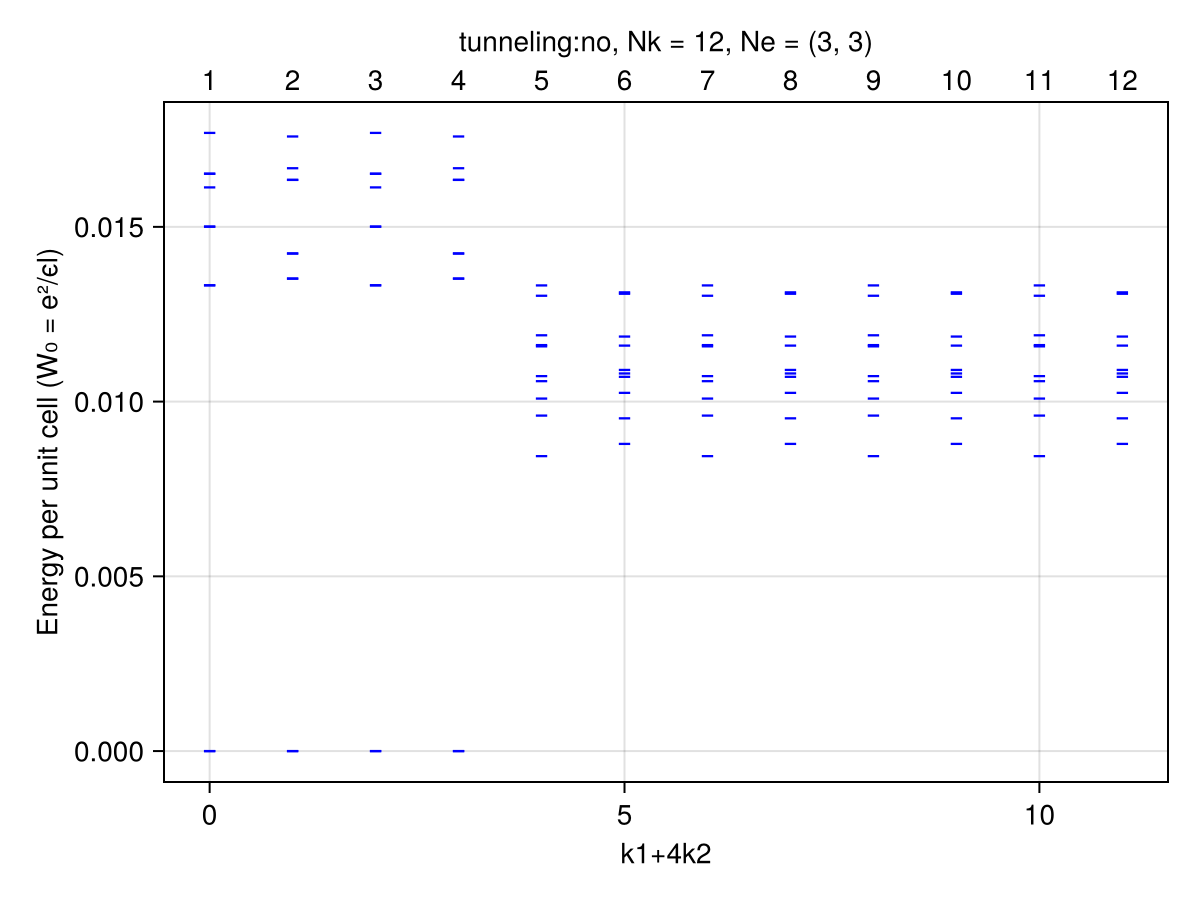

In [10]:
plot_ed_spectrum(energies/Nk/LLT.W0, ss_k, Gk;
    title = "tunneling:no, Nk = $Nk, Ne = $Ne",
    # ylims = (0.845, 0.847),
);

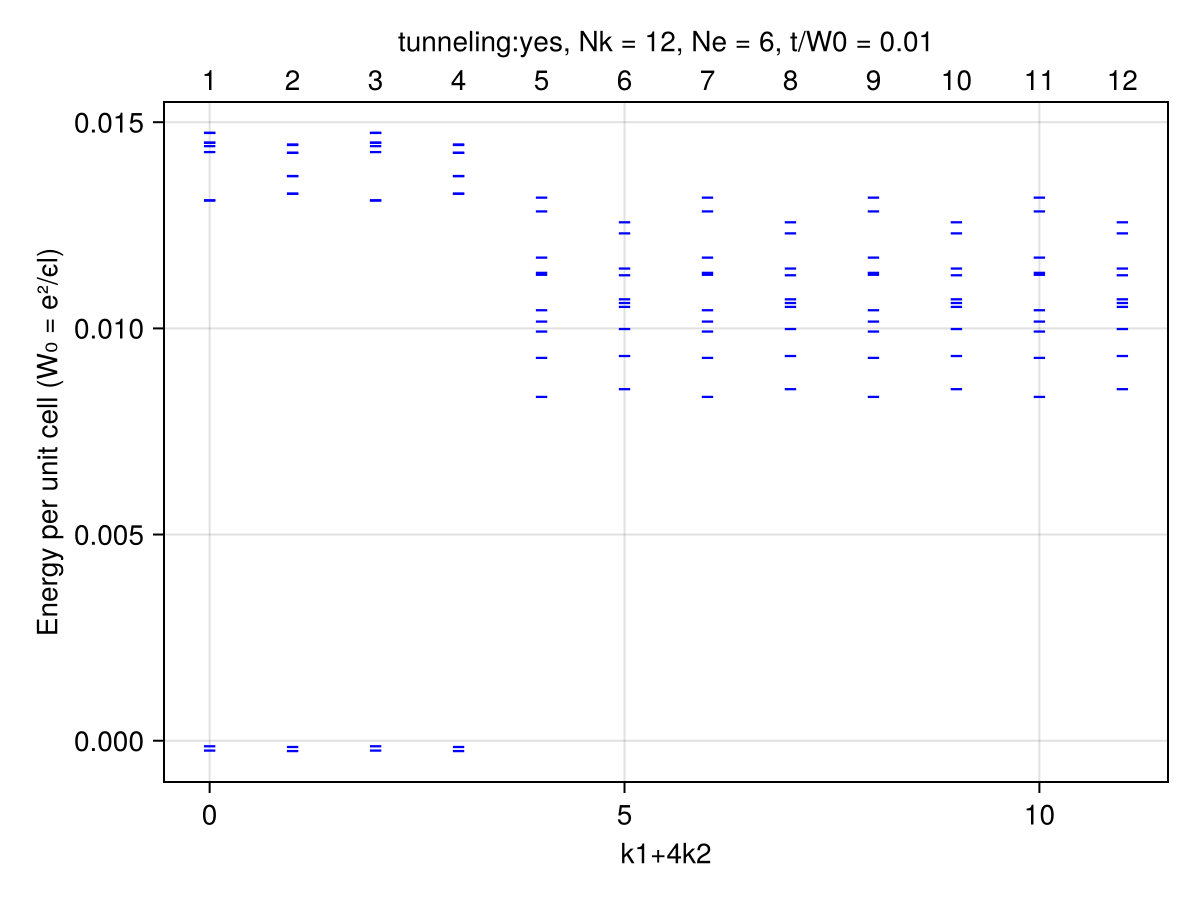

In [11]:
plot_ed_spectrum(energies_tunnel/Nk/LLT.W0, ss_tunnel_k, Gk;
    title = "tunneling:yes, Nk = $Nk, Ne = $Ne_total, t/W0 = $t_W0",
    # ylims = (0.845, 0.847),
);

In [12]:
# check energies explicitly to see degeneracy.
sn = 1        # the subspace number to inspect (see the top of spectrum plot)
display("total momentum: $(ss_k[sn])")
display("no tunneling:")
display(energies[sn]/Nk/LLT.W0)
display("tunneling:")
display(energies_tunnel[sn]/Nk/LLT.W0)

"total momentum: (0, 0)"

"no tunneling:"

10-element Vector{Float64}:
 3.5798149260981574e-17
 1.8498250198313258e-16
 0.013327917953517199
 0.013327917953517352
 0.01500644084388285
 0.015006440843883072
 0.01612920129091206
 0.0165202941999676
 0.016520294199967814
 0.017688431017110307

"tunneling:"

10-element Vector{Float64}:
 -0.00023890425586043325
 -0.0001341531705949217
  0.013103213334364304
  0.013103213334364643
  0.014275181142148714
  0.014419119909075762
  0.014502735247332475
  0.014502735247332572
  0.014740345728382813
  0.014740345728382858

Compute the many-body connection and the Wilson loop for many-body Chern number.

In [13]:
function manybody_overlap(para::EDPara, 
    ψ_f, ψ_i, k_f::Tuple{<:Real, <:Real}, k_i::Tuple{<:Real, <:Real})
    
    orbital_bc = orbital_overlap(para, k_f, k_i)
    return ED_step_inner_prod(ψ_f, ψ_i, orbital_bc)
end

manybody_overlap (generic function with 1 method)

In [14]:
# path for the Wilson loop integral on base manifold
# Landau level has uniform Berry curvature, so we compute Berry curvature of a small plaquate and then multiply plaquate number
N_kshift = 10  # number of shifts along G1 and G2 direction
path = Tuple{Rational, Rational}[(0//1, 0//1)]
push!(path, (1//N_kshift, 0//1))
push!(path, (1//N_kshift, 1//N_kshift))
push!(path, (0//1, 1//N_kshift))
push!(path, (0//1, 0//1))
display(path)

5-element Vector{Tuple{Rational, Rational}}:
 (0, 0)
 (1//10, 0)
 (1//10, 1//10)
 (0, 1//10)
 (0, 0)

In [15]:
# no tunneling
sn = 1; vn_range = 1:2;
psi = similar(path, Vector{typeof(vectors[sn][1])})
for i in eachindex(path)
    if i ∈ (1,5)
        psi[i] = vectors[sn][vn_range]
        continue
    end
    scat_list = ED_scatterlist_twobody(para; kshift = path[i]);
    hmlt_local = MBOperator(scat_list; upper_hermitian = true)
    psi[i] = EDsolve(subspaces[sn], hmlt_local; N = 6,
        showtime = false,
    )[2][vn_range]
end

WilsonLoopIntegral = Vector{Matrix{ComplexF64}}(undef, 4)
for i in eachindex(WilsonLoopIntegral)
    WilsonLoopIntegral[i] = manybody_overlap(para, 
    psi[i+1], psi[i], path[i+1], path[i])
end
ManyBodyChernNumber = angle(det(prod(WilsonLoopIntegral))) / (2π) * N_kshift^2
ManyBodyChernNumber /= length(vn_range)

0.4999999999999897

In [16]:
# with tunneling
sn = 1; vn_range = 1:2;
psi_tunnel = similar(path, Vector{typeof(vectors[sn][1])})
for i in eachindex(path)
    if i ∈ (1,5)
        psi_tunnel[i] = vectors_tunnel[sn][vn_range]
        continue
    end
    scat_list = ED_scatterlist_twobody(para_tunnel; kshift = path[i]);
    hmlt_tunnel_local = MBOperator(scat1_tunnel, scat_list; upper_hermitian = true)
    psi_tunnel[i] = EDsolve(subspaces_tunnel[sn], hmlt_tunnel_local; N = 6,
        showtime = false,
    )[2][vn_range]
end

WilsonLoopIntegral_tunnel = Vector{Matrix{ComplexF64}}(undef, 4)
for i in eachindex(WilsonLoopIntegral_tunnel)
    WilsonLoopIntegral_tunnel[i] = manybody_overlap(para_tunnel, 
    psi_tunnel[i+1], psi_tunnel[i], path[i+1], path[i])
end
ManyBodyChernNumber_tunnel = angle(det(prod(WilsonLoopIntegral_tunnel))) / (2π) * N_kshift^2
ManyBodyChernNumber_tunnel /= length(vn_range)

0.4999999999999485